# Load Import

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import load_data, preprocess_data
from src.kmeans import train_kmeans, evaluate_kmeans
from src.random_forest_model import train_random_forest, get_feature_importances
from src.neural_network import build_neural_network, train_neural_network
from src.evaluation import evaluate_model
from src.visualization import plot_heatmap, plot_feature_importance, plot_model_performance
import tensorflow as tf

import kagglehub
import shutil
import joblib
import warnings
warnings.filterwarnings('ignore')

/Volumes/T7/Coding/Projects BIT/DAI/Financial Security/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Acquisition

In [2]:
# Download latest version
path = kagglehub.dataset_download("jacklizhi/creditcard")
print("Downloaded to:", path)

# Copy all files to the project's data/ directory
data_dir = os.path.abspath('../data')
os.makedirs(data_dir, exist_ok=True)

for file in os.listdir(path):
    src = os.path.join(path, file)
    dst = os.path.join(data_dir, file)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
        print(f"Copied: {file} -> {data_dir}")

print("Done! Files stored in:", data_dir)


Downloaded to: /Users/amaylugun/.cache/kagglehub/datasets/jacklizhi/creditcard/versions/1
Copied: creditcard.csv -> /Volumes/T7/Coding/Projects BIT/DAI/Financial Security/data
Done! Files stored in: /Volumes/T7/Coding/Projects BIT/DAI/Financial Security/data


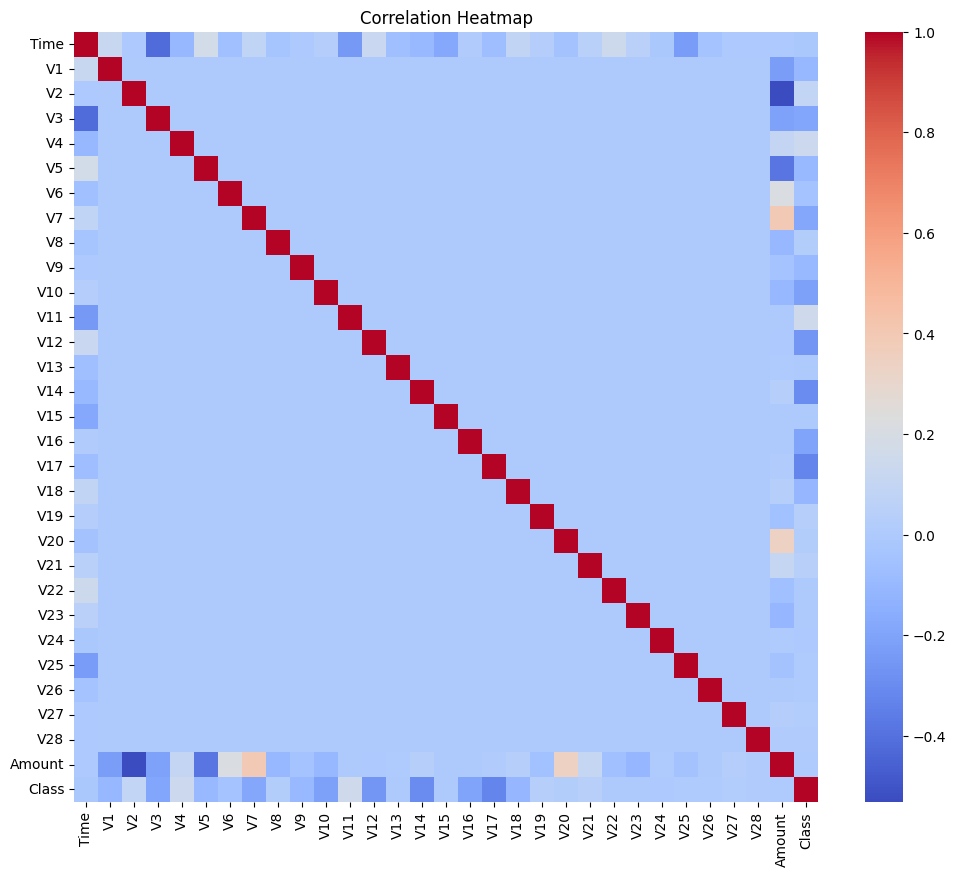

In [3]:
df = load_data('../data/creditcard.csv')
df.head()

df['Class'].value_counts()

fig = plot_heatmap(df)
plt.show()

## Preprocessing of data and balancing data using smote

In [4]:
X_train, X_test, y_train, y_test, scaler = preprocess_data(df, use_smote=True)

Kmeans

In [5]:
kmeans_model, clusters = train_kmeans(X_train)
kmeans_result = evaluate_kmeans(y_train, clusters)
print(kmeans_result)

Cluster       0      1
Actual                
0        227424     27
1        147292  80159


RandomForest

In [6]:
# Train on the training data
rf_model = train_random_forest(X_train, y_train)

# Predict probabilities and classes
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

# Evaluate using unified module
rf_results = evaluate_model(y_test, y_pred_rf, y_prob=y_prob_rf)

print("Recall (RF) : ", rf_results['recall'])
print("Confusion Matrix (RF): \n", rf_results['confusion_matrix'])
print("AUC-ROC (RF): ", rf_results.get('auc_roc', 'N/A'))

Recall (RF) :  0.826530612244898
Confusion Matrix (RF): 
 [[56852    12]
 [   17    81]]
AUC-ROC (RF):  0.9684455679429904


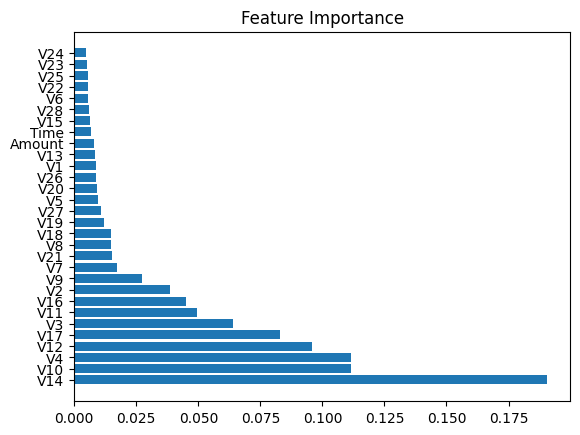

In [7]:
importances = get_feature_importances(rf_model)

fig = plot_feature_importance(importances, df.drop('Class', axis=1).columns)
plt.show()

Neural Network

In [8]:
nn_model = build_neural_network(X_train.shape[1])
nn_model = train_neural_network(nn_model, X_train, y_train, epochs=10)

# Predict probabilities and classes
y_prob_nn = nn_model.predict(X_test).flatten()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

# Evaluate using unified module
nn_results = evaluate_model(y_test, y_pred_nn, y_prob=y_prob_nn)

print("Recall (NN) :", nn_results['recall'])
print("Confusion Matrix (NN) :\n", nn_results['confusion_matrix'])
print("AUC-ROC (NN): ", nn_results.get('auc_roc', 'N/A'))

Epoch 1/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 11s 784us/step - Recall: 0.9663 - loss: 0.0680 - val_Recall: 0.9991 - val_loss: 0.0165
Epoch 2/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 9s 776us/step - Recall: 0.9918 - loss: 0.0299 - val_Recall: 0.9997 - val_loss: 0.0139
Epoch 3/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 9s 756us/step - Recall: 0.9941 - loss: 0.0237 - val_Recall: 0.9999 - val_loss: 0.0093
Epoch 4/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 9s 776us/step - Recall: 0.9953 - loss: 0.0207 - val_Recall: 0.9998 - val_loss: 0.0082
Epoch 5/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 10s 837us/step - Recall: 0.9965 - loss: 0.0172 - val_Recall: 0.9998 - val_loss: 0.0097
Epoch 6/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 10s 868us/step - Recall: 0.9968 - loss: 0.0168 - val_Recall: 0.9998 - val_loss: 0.0060
Epoch 7/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 10s 907us/step - Recall: 0.9969 - loss: 0.0149 - val_Recall: 1.0000 - val_loss: 0.0074
Epoch 8/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 9s 833us/step - Recall: 0.9971 - loss: 0.0

In [9]:
os.makedirs("../models", exist_ok=True)
joblib.dump(rf_model, "../models/rf_model.pkl")
nn_model.save("../models/nn_model.keras")

# Load Pretrained models

In [10]:
rf = joblib.load('../models/rf_model.pkl')
nn = tf.keras.models.load_model('../models/nn_model.keras')

### Evaluation Plots
Visualizing the performance using side-by-side matrices and curves.

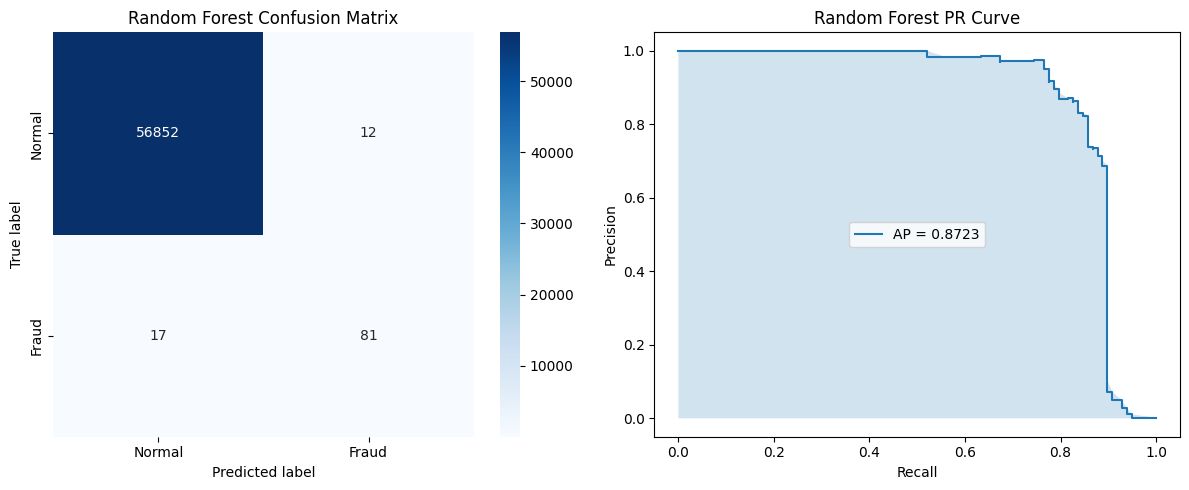

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step


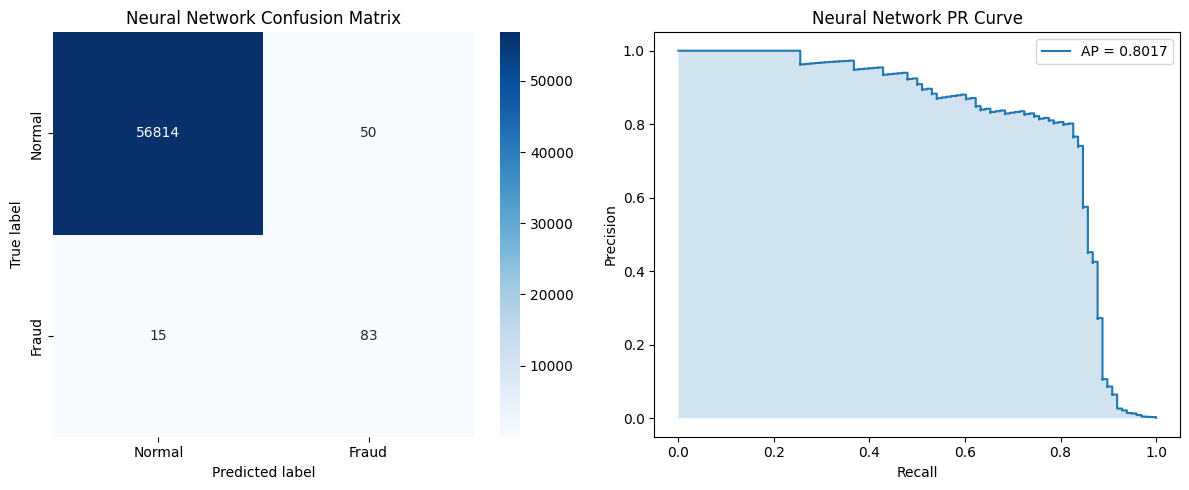

In [11]:
# Visualizing Random Forest results
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
plot_model_performance(y_test, y_prob_rf, title_suffix='Random Forest')
plt.show()

# Visualizing Neural Network results
y_prob_nn = nn_model.predict(X_test).flatten()
plot_model_performance(y_test, y_prob_nn, title_suffix='Neural Network')
plt.show()